In [443]:
# === Imports de base ===
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# === TensorFlow / Keras ===
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, Activation
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import RMSprop, SGD, Adam


# Affichage les images

In [444]:
# Taille de l'image
picture_size = 50

# Dossier contenant les images
folder_path = "data/images/train/Pepper__bell___Bacterial_spot"

# Classe à afficher
plante = 'pepper__bell_Bacterial_spot'

# Affichage de 9 images de la classe choisie
plt.figure(figsize=(20, 20))

<Figure size 2000x2000 with 0 Axes>

<Figure size 2000x2000 with 0 Axes>

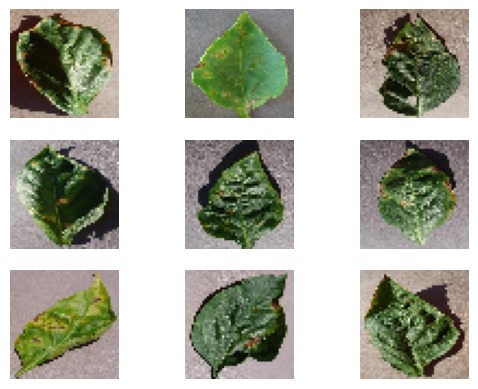

In [445]:
# Boucle pour afficher 9 images
for i in range(9):
    # Prendre le nom de l'image
    img_name = os.listdir(folder_path)[i]

    # Charger l'image et la redimensionner
    img = load_img(os.path.join(folder_path, img_name), target_size=(picture_size, picture_size))

    # Afficher l'image
    plt.subplot(3, 3, i + 1)
    plt.imshow(img)
    plt.axis('off')

plt.show()

In [446]:
# Taille des images
# picture_size = 48
picture_size = (48, 48)
# Chemin des dossiers
folder_path = "data/images/"

# Taille du lot (nombre d'images traitées à la fois)
batch_size = 128


# Générateurs d'images (pour charger et préparer les données)
datagen_train = ImageDataGenerator(rescale=1./255)     # Normalisation des pixels entre 0 et 1
datagen_val = ImageDataGenerator(rescale=1./255)



In [447]:
train_dir = os.path.join(folder_path, "train")
val_dir = os.path.join(folder_path, "validation")

# ------------------- Générateur pour l'entraînement -------------------
train_set = tf.keras.utils.image_dataset_from_directory(
    "data/images/train",
    labels="inferred",
    label_mode="categorical",   # Comme avec class_mode='categorical'
    image_size=picture_size,
    batch_size=batch_size,
    color_mode="grayscale",
    shuffle=True
)

# ------------------- Générateur pour la validation -------------------
val_set = tf.keras.utils.image_dataset_from_directory(
    "data/images/validation",
    labels="inferred",
    label_mode="categorical",
    image_size=picture_size,
    batch_size=batch_size,
    color_mode="grayscale",
    shuffle=False
)

Found 20638 files belonging to 15 classes.
Found 20638 files belonging to 15 classes.


In [448]:
# ------------------- Augmentation -------------------
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),        # retournement horizontal
    layers.RandomRotation(0.1),             # rotation aléatoire ±10%
    layers.RandomZoom(0.1),                 # zoom aléatoire
    layers.RandomTranslation(0.1, 0.1)      # décalage aléatoire
])

train_set = train_set.map(lambda x, y: (data_augmentation(x, training=True), y))

In [449]:
# Fonction de normalisation
def normalize(images, labels):
    images = tf.cast(images, tf.float32) / 255.0
    return images, labels

train_set = train_set.map(normalize)
val_set = val_set.map(normalize)


In [450]:
AUTOTUNE = tf.data.AUTOTUNE

train_set = train_set.cache().prefetch(buffer_size=AUTOTUNE)
val_set = val_set.cache().prefetch(buffer_size=AUTOTUNE)


In [451]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, Activation
from tensorflow.keras.regularizers import l2

model = Sequential()

# 1ère couche CNN
model.add(Conv2D(64, (3,3), padding='same', input_shape=(48, 48, 1),
                 kernel_regularizer=l2(0.01), bias_regularizer=l2(0.01)))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.25))

# 2ème couche CNN
model.add(Conv2D(128, (5,5), padding='same',
                 kernel_regularizer=l2(0.01), bias_regularizer=l2(0.01)))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.25))

# 3ème couche CNN
model.add(Conv2D(512, (3,3), padding='same',
                 kernel_regularizer=l2(0.01), bias_regularizer=l2(0.01)))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.25))

# 4ème couche CNN
model.add(Conv2D(512, (3,3), padding='same',kernel_regularizer=l2(0.01), bias_regularizer=l2(0.01)))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.25))

# Flatten
model.add(Flatten())

# Dense 1
model.add(Dense(256,kernel_regularizer=l2(0.01), bias_regularizer=l2(0.01)))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Dropout(0.25))

# Dense 2
model.add(Dense(512,kernel_regularizer=l2(0.01), bias_regularizer=l2(0.01)))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Dropout(0.25))

# Couche de sortie (7 émotions → pas 15)
model.add(Dense(15, activation='softmax'))


In [452]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [453]:
early_stopping = EarlyStopping(
    monitor='val_loss',        # on surveille la "perte" (loss) sur les données de validation
    patience=4,                # si aucune amélioration pendant 4 époques, on arrête l'entraînement
    restore_best_weights=True  # à la fin, on reprend les poids du meilleur modèle (on garde le meilleur, pas celui de la dernière époque)
)


checkpointer = ModelCheckpoint(
    filepath='model.weights.best.keras',  # nom du fichier pour sauvegarder le modèle
    verbose=1,                            # affiche un message quand le modèle est sauvegardé
    save_best_only=True                   # sauvegarde seulement le meilleur modèle (selon val_loss)
)
"""
But : sauvegarder ton modèle automatiquement à chaque amélioration sur les données de validation.
Le fichier model.weights.best.keras contiendra les poids du meilleur modèle que tu pourras recharger plus tard.
"""

reduce_learningrate = ReduceLROnPlateau(
    monitor='val_loss',     # On surveille la perte sur les données de validation.
    factor=0.2,             # On multiplie le learning rate actuel par 0.2 (réduction à 20%) quand la perte stagne.
    patience=3,             # On attend 3 époques sans amélioration avant de réduire le learning rate.
    verbose=1,              # Affiche un message quand le learning rate change.
    min_delta=0.0001        # La perte doit diminuer au moins de 0.0001 pour être considérée comme une amélioration.
)
"""
ReduceLROnPlateau est un callback qui sert à réduire automatiquement le taux d'apprentissage (learning rate) si le modèle n'apprend plus.
hajarkhalilmanalfarouQi.24800
Pourquoi ?
=> Le learning rate est la vitesse à laquelle le modèle ajuste ses poids.
=> Si la perte (val_loss) stagne, réduire le learning rate permet au modèle de faire des ajustements plus fins pour mieux converger.
"""

Entrai_model = model.fit(
    train_set,
    validation_data=val_set,
    epochs=40,
    callbacks=[checkpointer, early_stopping, reduce_learningrate]
)


Epoch 1/40
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - accuracy: 0.3067 - loss: 13.7094
Epoch 1: val_loss improved from inf to 7.08019, saving model to model.weights.best.keras
162/162 ━━━━━━━━━━━━━━━━━━━━ 48s 214ms/step - accuracy: 0.3072 - loss: 13.6827 - val_accuracy: 0.1753 - val_loss: 7.0802 - learning_rate: 0.0010
Epoch 2/40
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.4723 - loss: 3.5361
Epoch 2: val_loss improved from 7.08019 to 5.38088, saving model to model.weights.best.keras
162/162 ━━━━━━━━━━━━━━━━━━━━ 49s 67ms/step - accuracy: 0.4724 - loss: 3.5341 - val_accuracy: 0.1780 - val_loss: 5.3809 - learning_rate: 0.0010
Epoch 3/40
161/162 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.5239 - loss: 2.8045
Epoch 3: val_loss improved from 5.38088 to 5.36304, saving model to model.weights.best.keras
162/162 ━━━━━━━━━━━━━━━━━━━━ 11s 67ms/step - accuracy: 0.5240 - loss: 2.8036 - val_accuracy: 0.2536 - val_loss: 5.3630 - learning_rate: 0.0010
Epoch 4/40
161/162 ━━━━━━━━━━━━

In [454]:
# Charger les poids correspondant à la meilleure précision de validation
model.load_weights('model.weights.best.keras')

In [455]:
loss, accuracy = model.evaluate(val_set) # Demande au modèle de prédire sur toutes les images du dossier validation.

#? loss: Montre à quel point le modèle fait encore des erreurs (plus c'est bas, mieux c'est).
#? accuracy: Donne le pourcentage d'images correctement classées (plus c'est haut, mieux c'est).

print("=== Résultats de l'évaluation : ===")
print(f"Perte sur les données de validation : {loss:.4f}")
print(f"Précision sur les données de validation : {accuracy*100:.2f}%")


162/162 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.8285 - loss: 0.9060
=== Résultats de l'évaluation : ===
Perte sur les données de validation : 0.9932
Précision sur les données de validation : 80.26%


In [457]:
model.save("facial_detection_model.keras")